## **CQF Exam 3**

# **(I) Project Objectives**
<p>
The objective of this project is to develop a model to predict positive market moves on SPDR Gold Shares (Ticker: GLD) using Machine Learning (ML) techniques.
</p>

<p>
GLD is one of the largest exchange-traded funds (ETF) by asset under management (AUM), designed to track the spot price of physical gold. It was selected for several reasons: the ETF has two decades of trading history with ample data availability, maintains a high daily transaction volume, and its underlying asset is sensitive to macroeconomic factors — making it a strong candidate for ML classification with rich features to explore.
</p>
<p>
A five-year horizon from 2020-01-01 to 2025-12-31 is used, covering multiple macroeconomic regimes including the COVID-19 crash, the zero-rate era, the aggressive rate-hike cycle and the subsequent policy pivot.
</p>
<p>
Short-term asset returns are typically characterized by low-signal to noise ratios, potentially filled with small near-zero returns. Overfitting is therefore key risk, and XGBoost addresses this issue by incorporating a regularized objective function which combines the training loss with explicit penalties on tree structure (γ) and leaf weights (λ), discouraging the model from memorizing the noise in training data. XGBoost also has built-in early stopping, parallel tree construction and ability to handle missing values, making it a well-suited for multi-sourced, large feature sets which will be used in this study.
</p>
<p>
The success criteria is to maximize ROC-AUC. The model will also be evaluated using the F1 score, confusion matrix, and full classification report to identify optimal model parameters. The practical aim is to produce a model that achieves classification accuracy above 50% and generates tradable signals with potential for positive returns after deducting transaction costs.
</p>

## **A) Explanation of Entropy in Classification**
<p>
What does entropy reveal about the quality of the partitions in a classifiation problem?
</p>

Entropy measures the impurity or uncertainty of a partition in a classification problem. The formula is:

$$H(S) = -\sum_{i=1}^{C} p_i \log_2(p_i)$$

where:
- $C$ = number of classes
- $p_i$ = proportion of observations in class $i$ inside the partition
- $\log_2$ means log base 2
<br>
<p>
For binary classification, where classes are 0 and 1:
</p>
$$H(S) = -p \log_2(p) - (1-p) \log_2(1-p)$$
<br>
where $p$ is the proportion of class 1, and $1-p$ is the proportion of class 0.
<br>
<p>
A pure partition, where all observations belong to one class, entropy equal to zero because the partition is perfectly pure. At the other extreme is when entropy is at max where observations and its split is basically 50/50. </p><br>

| Class mix in partition | Entropy | Meaning |
|:---|:---|:---|
| 100% / 0% i.e. $-1.0\log_2(1.0) - 0\log_2(0)$ | 0 | Pure |
| 90% / 10% i.e. $-0.9\log_2(0.9) - 0.1\log_2(0.1)$ | 0.469 | Mostly pure |
| 70% / 30% i.e. $-0.7\log_2(0.7) - 0.3\log_2(0.3)$ | 0.881 | Some impurity |
| 50% / 50% i.e. $-0.5\log_2(0.5) - 0.5\log_2(0.5)$ | 1.000 | Most impure |

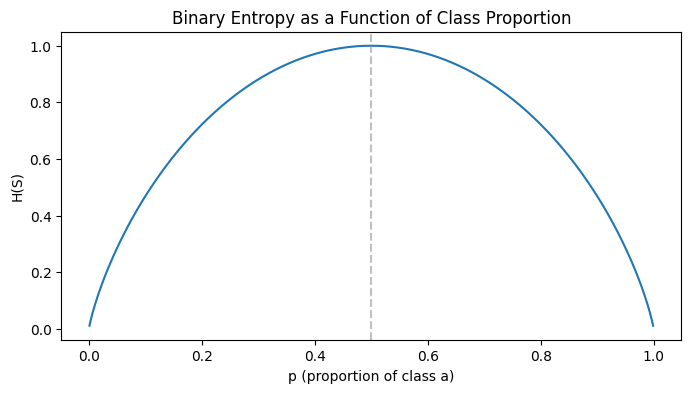

In [50]:
import numpy as np
import matplotlib.pyplot as plt

p = np.linspace(0.001, 0.999, 500)
H = -p * np.log2(p) - (1 - p) * np.log2(1 - p)

plt.figure(figsize=(8, 4))
plt.plot(p, H)
plt.xlabel('p (proportion of class a)')
plt.ylabel('H(S)')
plt.title('Binary Entropy as a Function of Class Proportion')
plt.axvline(x=0.5, linestyle='--', color='grey', alpha=0.5)
plt.show()

(a) High entropy means the partitions are pure - **False**
<p>
High entropy in this scenario would mean in the binary classification, classes (0, 1) are almost evenly split, meaning we are uncertain which class an observation should belong to, it is impure. </p>

(b) High entropy means the partitions are impure - **True**
<p>
As we just walked through in the above where high entropy is where classes (0, 1) is observed in different classes. Maximum entropy occurs when classes are evenly split and that signals partitions are impure. A good decision-tree split should reduce entropy in the child nodes, producing higher information gain. The information gain formula is defined as follow:
</p>

$$IG = H(\text{parent}) - \frac{|S_L|}{|S|} H(S_L) - \frac{|S_R|}{|S|} H(S_R)$$

<p>
At every tree split, the algorithm aims to select a split that maximizes IG, driving child nodes toward lower entropy (purer partitions).
</p>

<p>
Applying this to the GLD price direction prediction, each split with XGBoost will seek to separate positive-move days from negative-move days as cleanly as possible, reducing entropy at each node.
</p>


## **(II) Data Collection**

A range of factors impact spot gold and GLD price. Broadly, these are the key categories:

1) Macroeconomic Factors – economic cycles, inflation expectations, central bank reserves and policies, credit conditions

2) Yields/ Currency – policy rates (fed funds), treasury yields across the curve(real and nominal), yield curve shape, USD index, especially majority of gold is transacted in USD

3) Asset Price, Cross-Asset and Positioning – GLD technicals (e.g. momentum, volatility, transaction volume, Bollinger Bands), gold to silver ratio, gold miner (GDX), equity index (SPY), bond ETFs (TLT), options/ futures position (speculative positioning from CFTC COT data)

4) Geopolitics and Risk Sentiment – VIX, equities drawdown, credit spreads (as proxy for market stress), war (e.g. Ukraine, Iran war), central bank policies (often country specific, geopolitical decision to increase gold holdings as a hedge or reserve)

Not all factors are accessible from public data sources, nor are they suitable. For example, certain gold price drivers such as wars, sanctions, central bank policy shifts are one-off/ structural change in nature; supply-side dynamics (e.g. miners output, refinery capacity) impact a much longer horizon. These are either too low in frequency or too lagged for daily directional classification or one-off events which is difficult to model. Therefore we will focus on extracting data from public sources such as Yahoo Finance, Federal Reserve Bank of St. Louis (FRED) and CFTC Commitments of Traders (COT).

Data extraction will cover approximately 5 years, aiming to ensure multiple market regimes are covered (COVID crisis, zero rate period, rate hike cycle, subsequent pivot). Data will be extracted for factors believed to impact the underlying asset, with features to be engineered after data extraction, initial EDA but before funneling into a more realistic features pipeline.


Full feature list includes:

| Source | Series | Description | Theme |
|:-------|:-------|:------------|:------|
| Yahoo Finance | GLD | SPDR Gold Shares ETF (OHLCV) | Underlying |
| | SLV | iShares Silver Trust | Cross-asset |
| | GDX | VanEck Gold Miners ETF | Cross-asset |
| | TLT | iShares 20+ Year Treasury Bond | Yields |
| | SPY | S&P 500 ETF | Risk sentiment |
| FRED | DGS10 | 10-Year Treasury yield | Yields |
| | DFII10 | 10-Year TIPS yield (real) | Yields |
| | T10YIE | 10-Year breakeven inflation | Macro |
| | T10Y2Y | 10Y–2Y yield curve spread | Yields |
| | DFF | Federal funds effective rate | Macro |
| | DTWEXBGS | Broad trade-weighted USD index | Currency |
| | VIXCLS | CBOE VIX | Risk sentiment |
| | BAMLC0A0CM | ICE BofA US corporate spread | Risk sentiment |
| | DCOILWTICO | WTI crude oil price | Macro |
| CFTC COT | Gold futures | Spec long/short, commercial, OI | Positioning |

**a) Install Packages & Import Libraries**

In [51]:
# Install packages
!pip install -q cot_reports yfinance fredapi
!pip install -q xgboost wandb pyfolio-reloaded

In [52]:
# Mount the drive
from google.colab import drive
drive.mount('/content/drive')

# Change directory
import os
os.chdir("/content/drive/MyDrive/Colab Notebooks/CQF")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [53]:
# For data wrangling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For features data extraction
import yfinance as yf
from fredapi import Fred
from cot_reports import cot_year

**b) Data Extraction**

i) Yahoo Finance

In [54]:
# Data Extraction from Yahoo Finance

# Define tickers and date range
tickers     = ['GLD', 'SLV', 'GDX', 'TLT', 'SPY']
start_date  = '2019-06-01'  # buffer before 2020-01-01 for rolling window warmup
end_date    = '2025-12-31'

# File save path
SAVE_PATH = '/content/drive/MyDrive/Colab Notebooks/CQF/data'

# GLD: full Adjusted OHLCV (needed for technical features)
df_gld = yf.download('GLD', start=start_date, end=end_date, auto_adjust=True, progress=False)
df_gld.columns = [f'GLD_{col}' for col in df_gld.columns.get_level_values('Price')]

# Cross-asset tickers: Adjusted Close only
cross_tickers = ['SLV', 'GDX', 'TLT', 'SPY']
df_cross = yf.download(cross_tickers, start=start_date, end=end_date, auto_adjust=True, progress=False)['Close']
df_cross.columns = [f'{col}_Close' for col in df_cross.columns]

# Merge into one flat DataFrame and save to google drive
df_yf = pd.concat([df_gld, df_cross], axis=1)
df_yf.to_csv(os.path.join(SAVE_PATH, 'raw_yfinance.csv'))

In [55]:
# High level Data Quality Check
print(f"Shape: {df_yf.shape}")
print(f"Date range: {df_yf.index.min()} to {df_yf.index.max()}")
print(f"\nMissing values:\n{df_yf.isnull().sum()}")

Shape: (1655, 9)
Date range: 2019-06-03 00:00:00 to 2025-12-30 00:00:00

Missing values:
GLD_Close     0
GLD_High      0
GLD_Low       0
GLD_Open      0
GLD_Volume    0
GDX_Close     0
SLV_Close     0
SPY_Close     0
TLT_Close     0
dtype: int64


In [56]:
print(f"\nColumns: {df_yf.columns.tolist()}")
df_yf.head()


Columns: ['GLD_Close', 'GLD_High', 'GLD_Low', 'GLD_Open', 'GLD_Volume', 'GDX_Close', 'SLV_Close', 'SPY_Close', 'TLT_Close']


,GLD_Close,GLD_High,GLD_Low,GLD_Open,GLD_Volume,GDX_Close,SLV_Close,SPY_Close,TLT_Close
Date,,,,,,,,,
2019-06-03,125.110001,125.339996,123.900002,124.089996,14173600,20.727974,13.87,247.342239,108.584007
2019-06-04,125.150002,125.419998,124.610001,124.879997,7997100,20.820139,13.89,252.711197,107.346031
2019-06-05,125.470001,126.370003,125.239998,126.180000,7637900,20.857004,13.88,254.900269,106.739334
2019-06-06,125.879997,126.449997,125.800003,125.930000,5551800,21.078201,13.92,256.557770,107.083687
2019-06-07,126.589996,127.250000,126.320000,126.790001,8145900,21.096638,14.06,259.125092,108.010101


ii) FRED

In [57]:
# FRED API key from Colab Secrets
from google.colab import userdata
fred = Fred(api_key=userdata.get('FRED'))

# Date Parameters
start_date  = '2019-06-01'  # buffer before 2020-01-01 for rolling window warmup
end_date = '2025-12-31'

# File save path
SAVE_PATH = '/content/drive/MyDrive/Colab Notebooks/CQF/data'

# Define FRED series
fred_series = {
    'DGS10':      '10-Year Treasury Yield',
    'DFII10':     '10-Year TIPS (Real Yield)',
    'T10YIE':     '10-Year Breakeven Inflation',
    'T10Y2Y':     'Yield Curve (10Y-2Y)',
    'DFF':        'Fed Funds Effective Rate',
    'DTWEXBGS':   'Broad Trade-Weighted USD Index',
    'VIXCLS':     'CBOE VIX',
    'BAMLC0A0CM': 'ICE BofA US Corporate Spread',
    'DCOILWTICO': 'WTI Crude Oil',
}

# Download each series
df_fred = pd.DataFrame()
for code, desc in fred_series.items():
    try:
        s = fred.get_series(code, observation_start=start_date, observation_end=end_date)
        df_fred[code] = s
    except Exception as e:
        print(f"  {code:15s} FAILED: {e}")

df_fred.to_csv(os.path.join(SAVE_PATH, 'raw_fred.csv'))

In [58]:
# High level Data Quality Check
print(f"\nShape: {df_fred.shape}")
print(f"Date range: {df_fred.index.min()} to {df_fred.index.max()}")
print(f"\nMissing values:\n{df_fred.isnull().sum()}")


Shape: (1718, 9)
Date range: 2019-06-03 00:00:00 to 2025-12-31 00:00:00

Missing values:
DGS10           72
DFII10          72
T10YIE          72
T10Y2Y          72
DFF              0
DTWEXBGS        74
VIXCLS          35
BAMLC0A0CM    1043
DCOILWTICO      72
dtype: int64


In [59]:
print(f"\nColumns: {df_fred.columns.tolist()}")
display(df_fred.head())


Columns: ['DGS10', 'DFII10', 'T10YIE', 'T10Y2Y', 'DFF', 'DTWEXBGS', 'VIXCLS', 'BAMLC0A0CM', 'DCOILWTICO']


,DGS10,DFII10,T10YIE,T10Y2Y,DFF,DTWEXBGS,VIXCLS,BAMLC0A0CM,DCOILWTICO
2019-06-03,2.07,0.34,1.73,0.25,2.38,116.4764,18.86,NaN,53.25
2019-06-04,2.12,0.38,1.74,0.24,2.38,116.0910,16.97,NaN,53.50
2019-06-05,2.12,0.37,1.75,0.29,2.38,116.0300,16.09,NaN,51.57
2019-06-06,2.12,0.39,1.73,0.24,2.37,115.9771,15.93,NaN,52.59
2019-06-07,2.09,0.35,1.74,0.24,2.37,115.7368,16.30,NaN,53.95


iii) CFTC COT

In [60]:
# File save path
SAVE_PATH = '/content/drive/MyDrive/Colab Notebooks/CQF/data'

# Columns to keep and their clean names
cot_cols = {
    'Open Interest (All)'                 :'COT_OI',
    'Noncommercial Positions-Long (All)'  :'COT_Spec_Long',
    'Noncommercial Positions-Short (All)' :'COT_Spec_Short',
    'Commercial Positions-Long (All)'     :'COT_Comm_Long',
    'Commercial Positions-Short (All)'    :'COT_Comm_Short',
}

# Download, filter Gold, select columns
# date range to extract reports
years = range(2019, 2026)

frames = []
for year in years:
    df = cot_year(year, cot_report_type='legacy_fut')
    gold = df[df['Market and Exchange Names'].str.contains('GOLD', case=False)]
    frames.append(gold)

df_cot_gold = (
    pd.concat(frames, ignore_index=True)
    .assign(Date=lambda d: pd.to_datetime(d['As of Date in Form YYYY-MM-DD']))
    .set_index('Date')
    .sort_index()
    [list(cot_cols.keys())]
    .rename(columns=cot_cols)
    .apply(pd.to_numeric, errors='coerce')
)

df_cot_gold.to_csv(os.path.join(SAVE_PATH, 'raw_cot_gold.csv'))

Selected: legacy_fut
Downloaded single year data from: 2019
Stored the file annual.txt in the working directory.
Selected: legacy_fut
Downloaded single year data from: 2020
Stored the file annual.txt in the working directory.
Selected: legacy_fut
Downloaded single year data from: 2021
Stored the file annual.txt in the working directory.
Selected: legacy_fut
Downloaded single year data from: 2022
Stored the file annual.txt in the working directory.
Selected: legacy_fut
Downloaded single year data from: 2023
Stored the file annual.txt in the working directory.
Selected: legacy_fut
Downloaded single year data from: 2024
Stored the file annual.txt in the working directory.
Selected: legacy_fut
Downloaded single year data from: 2025
Stored the file annual.txt in the working directory.


In [61]:
# High level Data Quality Check
print(f"\nShape: {df_cot_gold.shape}")
print(f"Date range: {df_cot_gold.index.min()} to {df_cot_gold.index.max()}")
print(f"\nMissing values:\n{df_cot_gold.isnull().sum()}")


Shape: (492, 5)
Date range: 2019-01-08 00:00:00 to 2025-12-30 00:00:00

Missing values:
COT_OI            0
COT_Spec_Long     0
COT_Spec_Short    0
COT_Comm_Long     0
COT_Comm_Short    0
dtype: int64


In [62]:
df_cot_gold.head()

,COT_OI,COT_Spec_Long,COT_Spec_Short,COT_Comm_Long,COT_Comm_Short
Date,,,,,
2019-01-08,455232,199560,100344,137605,258792
2019-01-15,501605,201796,113883,179059,287172
2019-01-22,513509,186510,112006,197278,289355
2019-01-29,483390,212318,112725,163922,282531
2019-02-05,479736,218200,109105,157588,288830


c) Data Cleaning

i) Examining NAN values in FRED df

At a first pass, FRED data has NAN values, with BAMLC0A0CM (credit Spread) missing 900+ bars. Investigation required.

In [63]:
print("\nSample of NaN dates across yield series:")
nan_dates = df_fred[df_fred['DGS10'].isnull()].index[:10]
print(nan_dates)

print("\n\nBAMLC0A0CM (credit spread) — first valid date:")
df_fred['BAMLC0A0CM'].first_valid_index()




Sample of NaN dates across yield series:
DatetimeIndex(['2019-07-04', '2019-09-02', '2019-10-14', '2019-11-11',
               '2019-11-28', '2019-12-25', '2020-01-01', '2020-01-20',
               '2020-02-17', '2020-04-10'],
              dtype='datetime64[ns]', freq=None)


BAMLC0A0CM (credit spread) — first valid date:


Timestamp('2023-05-22 00:00:00')

On FRED NAN dates - dates listed above, are non-trading days. This will be adjsuted with ffill, same process for other data sources. <br>

Re BAMLC0A0CM (Credit spread), this data series it not usable for ML training as there is insufficient data, earliest start date only in 2023-05-22 leaving us 2.5 years of data for training and testing. <br>

ICE BofA US High Yield Index Option-Adjusted Spread data has been explored as an alternative. However, we encountered same issue where earliest data availability only starts from 2023-05. <br>

Conclusion: BAMLC0A0CM is dropped from the FRED dataset and replaced with Moody's BAA Corporate Bond Yield (DBAA), The credit spread will become an engineered feature using BAA yield minus 10-Year Treasury. This will be addressed in the feature engineering process.


In [64]:
# Replace credit spread series with Moody's BAA yield
df_fred = df_fred.drop(columns=['BAMLC0A0CM'])
df_fred['DBAA'] = fred.get_series('DBAA', observation_start='2019-12-01', observation_end='2025-12-31')

print(f"Shape: {df_fred.shape}")
print(f"\nMissing values:\n{df_fred.isnull().sum()}")

Shape: (1718, 9)

Missing values:
DGS10          72
DFII10         72
T10YIE         72
T10Y2Y         72
DFF             0
DTWEXBGS       74
VIXCLS         35
DCOILWTICO     72
DBAA          198
dtype: int64


In [65]:
print(f"Duplicate dates: {df_cot_gold.index.duplicated().sum()}")
print(f"\nDuplicate rows:")
display(df_cot_gold[df_cot_gold.index.duplicated(keep=False)].head(10))

Duplicate dates: 127

Duplicate rows:


,COT_OI,COT_Spec_Long,COT_Spec_Short,COT_Comm_Long,COT_Comm_Short
Date,,,,,
2020-12-01,32377,15096,13979,0,0
2020-12-01,538042,324344,64030,110108,403371
2020-12-29,556414,341812,72940,101283,408537
2020-12-29,34210,15798,22384,0,0
2021-05-18,33854,10031,12915,0,0
2021-05-18,520410,290267,91378,121839,354740
2021-08-17,485485,284437,92895,123301,337301
2021-08-17,32480,14107,8528,0,0
2021-09-07,34633,8491,9756,0,0


ii) merge all df together for further data cleaning and pre-processing

In [66]:
SAVE_PATH = '/content/drive/MyDrive/Colab Notebooks/CQF/data/'

# Load raw data
# df_yf = pd.read_csv(SAVE_PATH + 'raw_yfinance.csv', index_col=0, parse_dates=True)
# df_fred = pd.read_csv(SAVE_PATH + 'raw_fred.csv', index_col=0, parse_dates=True)
# df_cot = pd.read_csv(SAVE_PATH + 'raw_cot_gold.csv', index_col=0, parse_dates=True)

# Step 1: GLD trading dates = master calendar
master_idx = df_yf.index

# Step 2: Reindex FRED to GLD calendar, forward-fill
df_fred_aligned = df_fred.reindex(master_idx).ffill()

# Step 3: Reindex COT to GLD calendar, forward-fill
# Remove duplicate dates (aggregate if multiple gold contracts per week)
df_cot_dedup = df_cot_gold.groupby(df_cot_gold.index).sum()

# COT is Tuesday snapshot, published Friday — shift forward 4 business days
# so the model first sees it on the following Monday (no lookahead bias)
df_cot_aligned = (
    df_cot_dedup
    .shift(freq=pd.tseries.offsets.BDay(4))  # Tue → next Mon
    .reindex(master_idx)
    .ffill()
)

# Step 4: Merge all into one DataFrame
df_merged = pd.concat([df_yf, df_fred_aligned, df_cot_aligned], axis=1)

In [67]:
# High level data audit
print(f"Shape: {df_merged.shape}")
print(f"Date range: {df_merged.index.min()} to {df_merged.index.max()}")
print(f"\nMissing values:\n{df_merged.isnull().sum()}")
print(f"\nTotal NaN: {df_merged.isnull().sum().sum()}")

Shape: (1655, 23)
Date range: 2019-06-03 00:00:00 to 2025-12-30 00:00:00

Missing values:
GLD_Close           0
GLD_High            0
GLD_Low             0
GLD_Open            0
GLD_Volume          0
GDX_Close           0
SLV_Close           0
SPY_Close           0
TLT_Close           0
DGS10               0
DFII10              0
T10YIE              0
T10Y2Y              0
DFF                 0
DTWEXBGS            0
VIXCLS              0
DCOILWTICO          0
DBAA              127
COT_OI              0
COT_Spec_Long       0
COT_Spec_Short      0
COT_Comm_Long       0
COT_Comm_Short      0
dtype: int64

Total NaN: 127


In [68]:
df_merged.head()

,GLD_Close,GLD_High,GLD_Low,GLD_Open,GLD_Volume,GDX_Close,SLV_Close,SPY_Close,TLT_Close,DGS10,...,DFF,DTWEXBGS,VIXCLS,DCOILWTICO,DBAA,COT_OI,COT_Spec_Long,COT_Spec_Short,COT_Comm_Long,COT_Comm_Short
Date,,,,,,,,,,,,,,,,,,,,,
2019-06-03,125.110001,125.339996,123.900002,124.089996,14173600,20.727974,13.87,247.342239,108.584007,2.07,...,2.38,116.4764,18.86,53.25,NaN,505126.0,194463.0,107775.0,191290.0,301244.0
2019-06-04,125.150002,125.419998,124.610001,124.879997,7997100,20.820139,13.89,252.711197,107.346031,2.12,...,2.38,116.0910,16.97,53.50,NaN,505126.0,194463.0,107775.0,191290.0,301244.0
2019-06-05,125.470001,126.370003,125.239998,126.180000,7637900,20.857004,13.88,254.900269,106.739334,2.12,...,2.38,116.0300,16.09,51.57,NaN,505126.0,194463.0,107775.0,191290.0,301244.0
2019-06-06,125.879997,126.449997,125.800003,125.930000,5551800,21.078201,13.92,256.557770,107.083687,2.12,...,2.37,115.9771,15.93,52.59,NaN,505126.0,194463.0,107775.0,191290.0,301244.0
2019-06-07,126.589996,127.250000,126.320000,126.790001,8145900,21.096638,14.06,259.125092,108.010101,2.09,...,2.37,115.7368,16.30,53.95,NaN,505126.0,194463.0,107775.0,191290.0,301244.0


In [69]:
# Sanity check if there are 0 left in columns
print("Zero counts per column:")
print((df_merged == 0).sum())
print(f"\nDescriptive stats:")
display(df_merged.describe().T)

Zero counts per column:
GLD_Close         0
GLD_High          0
GLD_Low           0
GLD_Open          0
GLD_Volume        0
GDX_Close         0
SLV_Close         0
SPY_Close         0
TLT_Close         0
DGS10             0
DFII10            5
T10YIE            0
T10Y2Y            7
DFF               0
DTWEXBGS          0
VIXCLS            0
DCOILWTICO        0
DBAA              0
COT_OI            0
COT_Spec_Long     0
COT_Spec_Short    0
COT_Comm_Long     0
COT_Comm_Short    0
dtype: int64

Descriptive stats:


,count,mean,std,min,25%,50%,75%,max
GLD_Close,1655.0,1.976096e+02,5.855638e+01,1.251100e+02,1.649200e+02,1.770800e+02,2.152850e+02,4.167400e+02
GLD_High,1655.0,1.984801e+02,5.884390e+01,1.253400e+02,1.656500e+02,1.776100e+02,2.160600e+02,4.184500e+02
GLD_Low,1655.0,1.966182e+02,5.810977e+01,1.239000e+02,1.641850e+02,1.763700e+02,2.144450e+02,4.147500e+02
GLD_Open,1655.0,1.975944e+02,5.853727e+01,1.240900e+02,1.649950e+02,1.769600e+02,2.152900e+02,4.164800e+02
GLD_Volume,1655.0,9.201960e+06,5.354843e+06,1.436500e+06,5.807650e+06,7.888300e+06,1.093500e+07,6.202500e+07
GDX_Close,1655.0,3.449188e+01,1.197084e+01,1.763556e+01,2.768083e+01,3.125663e+01,3.643499e+01,9.129000e+01
SLV_Close,1655.0,2.358957e+01,7.378327e+00,1.121000e+01,1.973000e+01,2.220000e+01,2.586000e+01,7.112000e+01
SPY_Close,1655.0,4.245402e+02,1.141256e+02,2.049449e+02,3.477248e+02,4.068073e+02,5.076161e+02,6.884997e+02
TLT_Close,1655.0,1.038547e+02,1.955101e+01,7.426585e+01,8.623773e+01,9.497375e+01,1.210780e+02,1.437900e+02
DGS10,1655.0,2.853873e+00,1.381999e+00,5.200000e-01,1.570000e+00,3.370000e+00,4.170000e+00,4.980000e+00


In [70]:
# save merged file to data folder
df_merged.to_csv(os.path.join(SAVE_PATH, 'cleaned_merged.csv'))

## **(III) EDA**

In [71]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/CQF/data/cleaned_merged.csv', index_col=0, parse_dates=True)
print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()

Shape: (1655, 23)
Date range: 2019-06-03 00:00:00 to 2025-12-30 00:00:00
Missing values: 127


,GLD_Close,GLD_High,GLD_Low,GLD_Open,GLD_Volume,GDX_Close,SLV_Close,SPY_Close,TLT_Close,DGS10,...,DFF,DTWEXBGS,VIXCLS,DCOILWTICO,DBAA,COT_OI,COT_Spec_Long,COT_Spec_Short,COT_Comm_Long,COT_Comm_Short
Date,,,,,,,,,,,,,,,,,,,,,
2019-06-03,125.110001,125.339996,123.900002,124.089996,14173600,20.727974,13.87,247.342239,108.584007,2.07,...,2.38,116.4764,18.86,53.25,NaN,505126.0,194463.0,107775.0,191290.0,301244.0
2019-06-04,125.150002,125.419998,124.610001,124.879997,7997100,20.820139,13.89,252.711197,107.346031,2.12,...,2.38,116.0910,16.97,53.50,NaN,505126.0,194463.0,107775.0,191290.0,301244.0
2019-06-05,125.470001,126.370003,125.239998,126.180000,7637900,20.857004,13.88,254.900269,106.739334,2.12,...,2.38,116.0300,16.09,51.57,NaN,505126.0,194463.0,107775.0,191290.0,301244.0
2019-06-06,125.879997,126.449997,125.800003,125.930000,5551800,21.078201,13.92,256.557770,107.083687,2.12,...,2.37,115.9771,15.93,52.59,NaN,505126.0,194463.0,107775.0,191290.0,301244.0
2019-06-07,126.589996,127.250000,126.320000,126.790001,8145900,21.096638,14.06,259.125092,108.010101,2.09,...,2.37,115.7368,16.30,53.95,NaN,505126.0,194463.0,107775.0,191290.0,301244.0


In [72]:
# Descriptive statistics
df.describe().T.style.format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
GLD_Close,1655.00,197.61,58.56,125.11,164.92,177.08,215.29,416.74
GLD_High,1655.00,198.48,58.84,125.34,165.65,177.61,216.06,418.45
GLD_Low,1655.00,196.62,58.11,123.90,164.18,176.37,214.44,414.75
GLD_Open,1655.00,197.59,58.54,124.09,165.00,176.96,215.29,416.48
GLD_Volume,1655.00,9201959.70,5354842.78,1436500.00,5807650.00,7888300.00,10935000.00,62025000.00
GDX_Close,1655.00,34.49,11.97,17.64,27.68,31.26,36.43,91.29
SLV_Close,1655.00,23.59,7.38,11.21,19.73,22.20,25.86,71.12
SPY_Close,1655.00,424.54,114.13,204.94,347.72,406.81,507.62,688.50
TLT_Close,1655.00,103.85,19.55,74.27,86.24,94.97,121.08,143.79
DGS10,1655.00,2.85,1.38,0.52,1.57,3.37,4.17,4.98


Descriptive statistics are revealing vastly different scales across the raw columns - from single digit yields percentages to trading volume in millions. This confirms that raw features will need to be transformed, normalized and engineered.

In [73]:
# Verify continuous trading day index (no unexpected gaps)
date_diffs = df.index.to_series().diff().dt.days
print(f"Min gap: {date_diffs.min()} days")
print(f"Max gap: {date_diffs.max()} days")
print(f"\nGap distribution:\n{date_diffs.value_counts().sort_index()}")

Min gap: 1.0 days
Max gap: 4.0 days

Gap distribution:
Date
1.0    1293
2.0      18
3.0     299
4.0      44
Name: count, dtype: int64


A date continuity check confirms no unexpected gaps in the trading day index — observed gaps of 1 to 4 calendar days correspond to weekday, weekend, and holiday patterns.

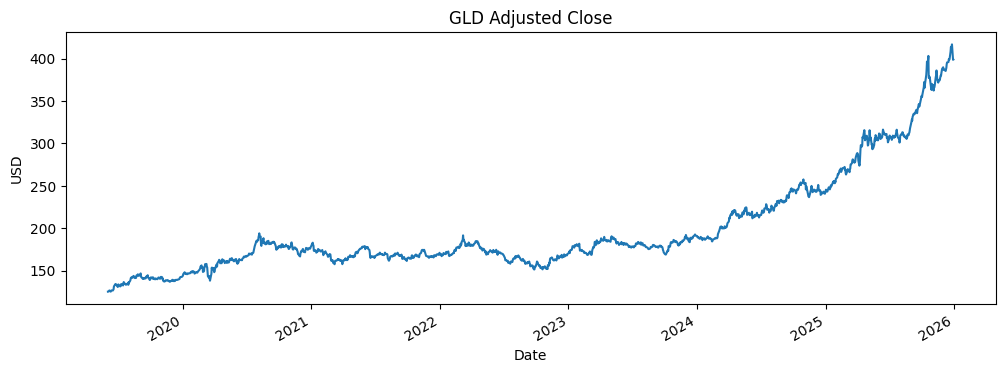

In [74]:
# GLD price history
df['GLD_Close'].plot(figsize=(12, 4), title='GLD Adjusted Close')
plt.ylabel('USD')
plt.show()

GLD has shown an upward trend, paritulcalry from mid-2024 onward. This long bias may result in a class imbalance toward positive returns, which will be examined during label construction.

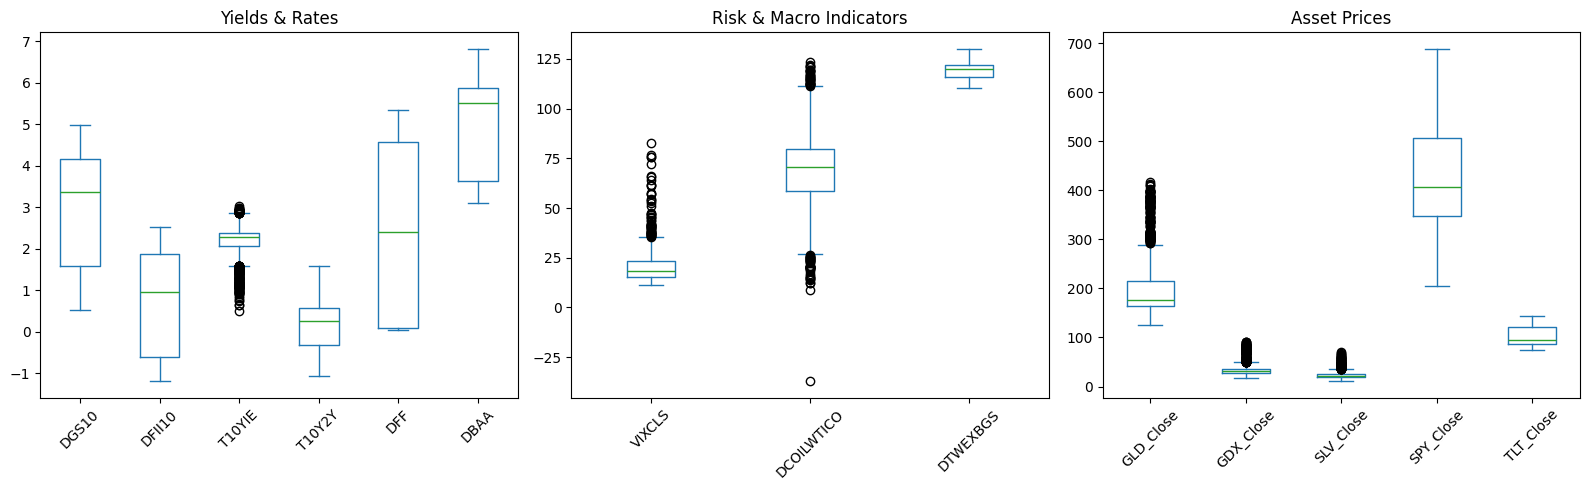

In [75]:
# Box plots — grouped by scale
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Yields & rates
df[['DGS10', 'DFII10', 'T10YIE', 'T10Y2Y', 'DFF', 'DBAA']].plot.box(ax=axes[0])
axes[0].set_title('Yields & Rates')
axes[0].tick_params(axis='x', rotation=45)

# Risk & macro
df[['VIXCLS', 'DCOILWTICO', 'DTWEXBGS']].plot.box(ax=axes[1])
axes[1].set_title('Risk & Macro Indicators')
axes[1].tick_params(axis='x', rotation=45)

# GLD OHLC only (not volume, not cross-asset)
df[['GLD_Close', 'GDX_Close', 'SLV_Close', 'SPY_Close', 'TLT_Close']].plot.box(ax=axes[2])
axes[2].set_title('Asset Prices')
# df[['GLD_Open', 'GLD_High', 'GLD_Low', 'GLD_Close']].plot.box(ax=axes[2])
# axes[2].set_title('GLD Price')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The box plots revealed notable outliers in VIX and Oil (COVID-er spike and WTI going negative in 2020). The assets – GLD, GDX, SLV all showing wide ranges with upper outliers, this matches with price breakthroughs late 2024-2025. SPY’s wide range is a good indicator we have covered different market regimes in the dataset.

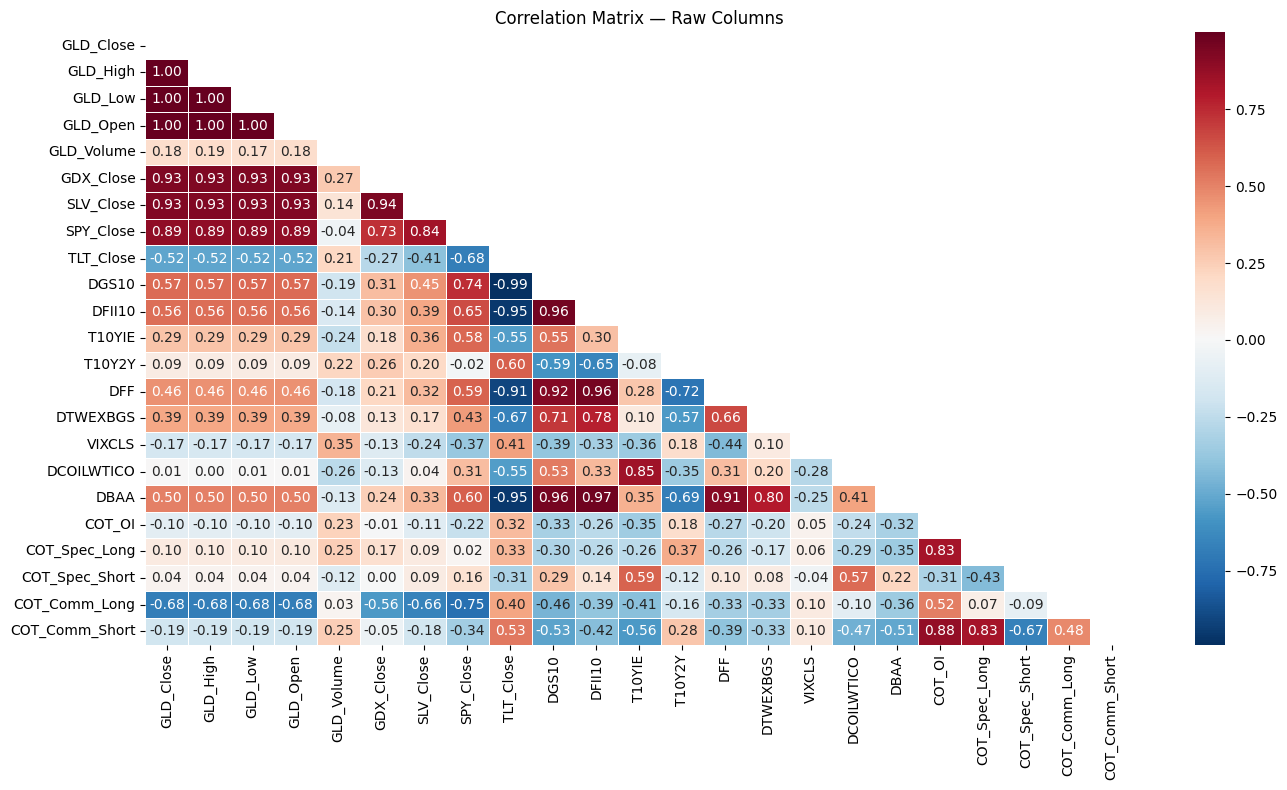

In [76]:
fig, ax = plt.subplots(figsize=(14, 8))
matrix = np.triu(df.corr())
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="RdBu_r", linewidths=0.5, ax=ax, mask=matrix)
ax.set_title("Correlation Matrix — Raw Columns")
plt.tight_layout()
plt.show()

The raw column correlation matrix is used as an exploratory diagnostic to understand common trends, potentially redundant variables and macro regimes. At this stage, they may not signal predictive relationships. Several observations:

1) potentially redundant variables – GLD OHLC almost identical, reinforcing the need to convert into ratios, returns, z-scores etc in feature engineering and likely to be dropped afterwards
2) potentially high colinear feature groups – Cross asset ETFs, COT variables, rate variables
3) understanding on broad market structure and relationships – TLT and commercial COT positionings are strongly negatively correlated with GLD price

## **(IV) Feature Engineering**

a) Target Variable Construction

Log returns are used to compute asset returns. This transforms non-stationary price series into relative changes that are more comparable across assets with different price scales. It also allows multi-period returns to be obtained by simple summation of single-period log returns. This makes it convenient to compare returns, volatility, momentum and target-label construction.

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right) = \ln(P_t) - \ln(P_{t-1})$$

To construct the target variable, we first compute daily log returns and first examine and understand the series from these aspects:

1) Are the returns stationary – or does it cluster around volatility clustering and regimes across peirod
2) The returns distribution profile – does it shape around zero, dominated by small moves or it looks choppy and dispersed
3) Statistical behavior – is the return series skewed, biased towards positive/ negative moves or dominated by outliers

These inform the choice of the boundary below which daily returns are treated as noise rather than genuine directional signals, and the resulting binary label assignment


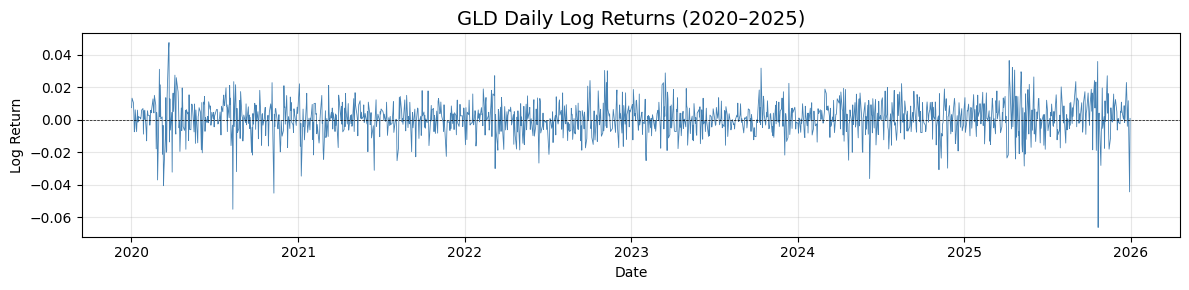

In [77]:
# Compute daily log returns from GLD adjusted close
df['GLD_LogRet'] = np.log(df['GLD_Close']).diff()

# Plot daily log returns over time
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(df.loc['2020':].index, df.loc['2020':, 'GLD_LogRet'], linewidth=0.6, color='steelblue')
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_title('GLD Daily Log Returns (2020–2025)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Log Return')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The return distribution is examined to identify the appropriate dead-zone threshold for near-zero returns that carry no meaningful directional signal.

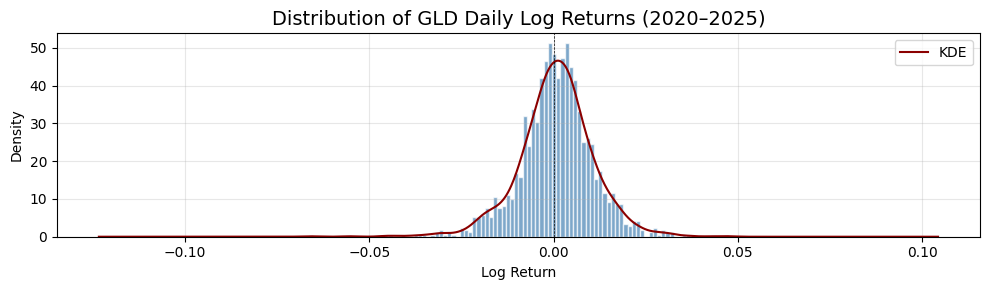

In [78]:
# Plot return distribution
ret = df.loc['2020':, 'GLD_LogRet']

fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(ret, bins=100, density=True, alpha=0.7, color='steelblue', edgecolor='white')
ret.plot.kde(ax=ax, color='darkred', linewidth=1.5, label='KDE')
ax.axvline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_title('Distribution of GLD Daily Log Returns (2020–2025)', fontsize=14)
ax.set_xlabel('Log Return')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [79]:
# Descriptive statistics of GLD daily log returns
ret = df.loc['2020':, 'GLD_LogRet']

stats = pd.DataFrame({
    'Statistic': ['Count', 'Mean', 'Median', 'Std Dev', 'Skewness', 'Kurtosis (excess)',
                  'Min', '5th Percentile', '25th Percentile', '75th Percentile',
                  '95th Percentile', 'Max'],
    'Value': [
        f"{len(ret):,.0f}",
        f"{ret.mean():.6f}",
        f"{ret.median():.6f}",
        f"{ret.std():.6f}",
        f"{ret.skew():.4f}",
        f"{ret.kurtosis():.4f}",
        f"{ret.min():.6f}",
        f"{ret.quantile(0.05):.6f}",
        f"{ret.quantile(0.25):.6f}",
        f"{ret.quantile(0.75):.6f}",
        f"{ret.quantile(0.95):.6f}",
        f"{ret.max():.6f}"
    ]
})

stats.style.hide(axis='index')

Statistic,Value
Count,"1,507"
Mean,0.000681
Median,0.000858
Std Dev,0.010309
Skewness,-0.4359
Kurtosis (excess),3.1915
Min,-0.066427
5th Percentile,-0.016459
25th Percentile,-0.004661
75th Percentile,0.006322


The descriptive statistics is with a mean of 0.069% is suggesting trending slightly positive, potentially creating class imbalance. With the skewness at -0.44, this illustrates drawdowns are larger than upward movements. Kurtosis is also suggesting the returns sereis have fat tails. <br>

The return distribution shows a concentration of near-zero observations that require a classification decision — either exclude them from the training dataset, or reclassify them. To select an appropriate threshold, we examine how observations fall within various bands. Setting the threshold too low retains noise in the labels; too high reduces the training sample and the model's ability to generalize.

In [80]:
# Count observations within candidate different thresholds
ret = df.loc['2020':, 'GLD_LogRet']
total = len(ret)
std = ret.std()

thresholds = [0.0005, 0.001, 0.0015, 0.002, 0.0025, 0.003, 0.005]

rows = []
for t in thresholds:
    in_zone = ret.abs() < t
    n_drop = in_zone.sum()
    rows.append({
        'Threshold': f'±{t:.4f} ({t*100:.2f}%)',
        'Fraction of σ': f'{t / std:.2f}σ',
        'Observations Dropped': n_drop,
        '% of Total': f'{n_drop / total * 100:.1f}%',
        'Remaining': total - n_drop
    })

threshold_df = pd.DataFrame(rows)
threshold_df.style.hide(axis='index')

Threshold,Fraction of σ,Observations Dropped,% of Total,Remaining
±0.0005 (0.05%),0.05σ,68,4.5%,1439
±0.0010 (0.10%),0.10σ,152,10.1%,1355
±0.0015 (0.15%),0.15σ,209,13.9%,1298
±0.0020 (0.20%),0.19σ,293,19.4%,1214
±0.0025 (0.25%),0.24σ,356,23.6%,1151
±0.0030 (0.30%),0.29σ,420,27.9%,1087
±0.0050 (0.50%),0.49σ,678,45.0%,829


Based on the analysis above, small positive returns below +0.0020 (0.20%) are classified as non-positive (label = 0). This treats moves within approximately 0.19 standard deviations of zero as carrying no meaningful directional signal — they are statistically indistinguishable from noise and economically marginal. It also retains the full dataset for training while producing a stricter definition of a positive move. In production, a volatility-adaptive threshold scaled to rolling local standard deviation would better account for regime shifts; for this study, a fixed threshold is used for simplicity and reproducibility.

The target variable is now defined as:

$$
y_t = \begin{cases} 1, & \text{if } r_t > 0.0020 \\ 0, & \text{otherwise} \end{cases}
$$

where $r_t = \ln(P_t) - \ln(P_{t-1})$ is the daily log return of GLD.

In [81]:
# Construct binary target variable
# Label = 1 if log return exceeds +0.20%, else 0
df['Label'] = np.where(df['GLD_LogRet'] > 0.002, 1, 0)

We examine the class distribution to check for imbalance, which may require adjustment during model training.

Class 0: 828 (54.9%)
Class 1: 679 (45.1%)


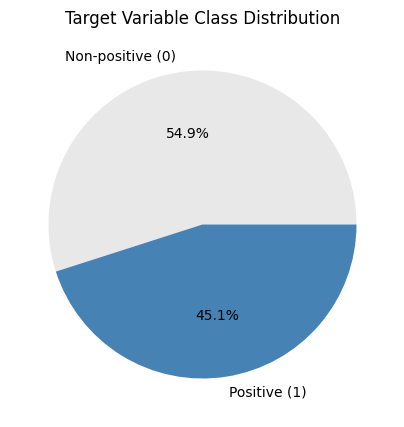

In [82]:
# Class balance
counts = df.loc['2020':, 'Label'].value_counts()
print(f"Class 0: {counts[0]} ({counts[0]/counts.sum()*100:.1f}%)")
print(f"Class 1: {counts[1]} ({counts[1]/counts.sum()*100:.1f}%)")

df.loc['2020':, 'Label'].value_counts().plot.pie(
    autopct='%1.1f%%',
    labels=['Non-positive (0)', 'Positive (1)'],
    colors=['#E8E8E8', 'steelblue'],
    figsize=(5, 5),
    title='Target Variable Class Distribution'
)
plt.ylabel('')
plt.show()

The class distribution is approximately balanced at 55/45, with a mild skew toward non-positive outcomes following the reclassification of near-zero returns. This moderate imbalance will be addressed using balanced sample weighting during model training.

b) Feature Engineering

The feature set is organized into four thematic categories, totaling approximately 47 engineered features derived from the 23 raw columns in the dataset. The categories reflect various information channels that drive gold price:

1. **Technical** (~20 features) — Price action, momentum, volatility, and volume patterns derived from GLD OHLCV data. These capture the dynamics of gold's own price process.

2. **Cross-Asset** (~9 features) — Relative performance and co-movement with related assets (silver, gold miners, equities, treasuries). Gold does not trade in isolation; its price responds to rotation across asset classes/ sectors.

3. **Macro** (~11 features) — Interest rates, real yields, inflation expectations, credit conditions, the US dollar, oil, and volatility. These are the fundamental drivers of gold's role as a real asset, inflation hedge, and safe haven.

4. **Positioning** (~7 features) — CFTC Commitments of Traders data capturing speculator and commercial hedger positioning in gold futures. Extreme positioning has historically preceded trend reversals.

Rolling window lengths of 7, 14, 28, and 63 trading days correspond approximately to 1-week, 2-week, 1-month, and 1-quarter horizons.

### Category 1: Technical Features (~20 features from GLD OHLCV)

Technical features extract information from GLD's own price and volume history. The core building blocks are:

- **Rolling cumulative returns** over 7, 14, 28, and 63 days capture momentum at multiple horizons. Log returns are additive, so the rolling sum equals the point-to-point log return over each window.
- **Rolling volatility** (standard deviation of daily log returns) measures the dispersion of returns at each horizon. Volatility clustering — visible in the time series plot above — means recent volatility is informative about near-term return distributions.
- **Bollinger %B** normalises the closing price's position within its Bollinger Band to a 0–1 scale: $\%B = (P - LB) / (UB - LB)$. Unlike raw band levels, %B is stationary and directly interpretable — values near 1 indicate price at the upper band, values near 0 at the lower band.
- **Intraday structure**: the open-to-close ratio captures the intraday directional body, the high-low range proxies intraday volatility, and the overnight gap captures information flow from Asian and European gold markets while US equity markets are closed.
- **RSI (14-day)** measures momentum as the ratio of average gains to average losses, mapped to a 0–100 scale. Values above 70 suggest overbought conditions; below 30 suggests oversold.
- **Volume percentage changes** capture shifts in trading activity — rising volume on directional moves often signals conviction behind the move.
- **Lagged return** (1-day) allows the model to detect any residual autocorrelation in daily returns.

In [83]:
# ── Category 1: Technical Features (~20 from GLD OHLCV) ──

# 1. Rolling cumulative log returns (4 features)
for w in [7, 14, 28, 63]:
    df[f'RollRet_{w}d'] = df['GLD_LogRet'].rolling(w).sum()

# 2. Rolling volatility — std of daily log returns (4 features)
for w in [7, 14, 28, 63]:
    df[f'RollVol_{w}d'] = df['GLD_LogRet'].rolling(w).std()

# 3. Bollinger %B — normalised band position (2 features)
for w in [14, 28]:
    sma = df['GLD_Close'].rolling(w).mean()
    std = df['GLD_Close'].rolling(w).std()
    ub = sma + 2 * std
    lb = sma - 2 * std
    df[f'BB_PctB_{w}d'] = (df['GLD_Close'] - lb) / (ub - lb)

# 4. Volume percentage change (3 features)
for w in [7, 14, 28]:
    df[f'VolChg_{w}d'] = df['GLD_Volume'].pct_change(w)

# 5. Intraday structure (3 features)
df['OC'] = (df['GLD_Close'] - df['GLD_Open']) / df['GLD_Open']    # open-to-close body
df['HL'] = (df['GLD_High'] - df['GLD_Low']) / df['GLD_Close']     # intraday range
df['GAP'] = df['GLD_Open'] / df['GLD_Close'].shift(1) - 1         # overnight gap

# 6. Rolling mean of overnight gap (1 feature)
df['GAP_14d'] = df['GAP'].rolling(14).mean()

# 7. RSI — 14-day, simple moving average variant (1 feature)
_gain = df['GLD_LogRet'].clip(lower=0)
_loss = -df['GLD_LogRet'].clip(upper=0)
_avg_gain = _gain.rolling(14).mean()
_avg_loss = _loss.rolling(14).mean()
df['RSI_14d'] = 100 - (100 / (1 + _avg_gain / _avg_loss))

# 8. Lagged return (1 feature)
df['LagRet_1d'] = df['GLD_LogRet'].shift(1)

# Clean up temp variables
del _gain, _loss, _avg_gain, _avg_loss

# ── Verify ──
cat1_features = [
    'GLD_LogRet',
    'RollRet_7d', 'RollRet_14d', 'RollRet_28d', 'RollRet_63d',
    'RollVol_7d', 'RollVol_14d', 'RollVol_28d', 'RollVol_63d',
    'BB_PctB_14d', 'BB_PctB_28d',
    'VolChg_7d', 'VolChg_14d', 'VolChg_28d',
    'OC', 'HL', 'GAP',
    'GAP_14d',
    'RSI_14d',
    'LagRet_1d'
]

print(f"Category 1: {len(cat1_features)} features")
df[cat1_features].head()

Category 1: 20 features


,GLD_LogRet,RollRet_7d,RollRet_14d,RollRet_28d,RollRet_63d,RollVol_7d,RollVol_14d,RollVol_28d,RollVol_63d,BB_PctB_14d,BB_PctB_28d,VolChg_7d,VolChg_14d,VolChg_28d,OC,HL,GAP,GAP_14d,RSI_14d,LagRet_1d
Date,,,,,,,,,,,,,,,,,,,,
2019-06-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.008220,0.011510,NaN,NaN,NaN,NaN
2019-06-04,0.000320,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002162,0.006472,-0.001838,NaN,NaN,NaN
2019-06-05,0.002554,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.005627,0.009006,0.008230,NaN,NaN,0.000320
2019-06-06,0.003262,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.000397,0.005164,0.003666,NaN,NaN,0.002554
2019-06-07,0.005624,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.001577,0.007347,0.007229,NaN,NaN,0.003262


In [84]:
# Check effective start date after dropna
print(f"First usable row: {df.dropna().index[0]}")
print(f"Last row: {df.dropna().index[-1]}")
print(f"Total usable observations: {len(df.dropna())}")

First usable row: 2019-12-02 00:00:00
Last row: 2025-12-30 00:00:00
Total usable observations: 1528


### Category 2: Cross-Asset Features (~9 features)

Gold's price dynamics are shaped by its relationships with related assets. These features capture relative valuation and co-movement across the precious metals complex, equities, and fixed income.

- **Cross-asset log returns** (GDX, SLV, SPY, TLT) provide same-day directional signals from related markets. Gold miners (GDX) tend to lead or amplify gold moves due to operating leverage. Silver (SLV) shares macro drivers but has higher industrial demand sensitivity. Equities (SPY) and treasuries (TLT) capture risk appetite and flight-to-safety flows respectively.
- **Gold/Silver ratio** (GLD/SLV) is a widely followed relative valuation metric — a rising ratio historically signals risk aversion and safe-haven demand for gold over silver.
- **Miner leverage ratio** (GDX/GLD) captures whether miners are outperforming or underperforming the metal itself, often an early signal of shifting sentiment in the gold complex.
- **Rolling correlations** (GLD vs SPY, GLD vs TLT over 28 days) measure the time-varying relationship between gold and broader markets. Gold's correlation with equities is regime-dependent — negative during crises, near-zero or positive during risk-on environments.
- **Relative performance** (GLD vs SPY 28-day cumulative return spread) captures medium-term rotation between gold and equities.

In [87]:
# ── Category 2: Cross-Asset Features (~9 features) ──

# 1. Cross-asset daily log returns (4 features)
for ticker in ['GDX', 'SLV', 'SPY', 'TLT']:
    df[f'{ticker}_LogRet'] = np.log(df[f'{ticker}_Close']).diff()

# 2. Gold/Silver ratio (1 feature)
df['GLD_SLV_Ratio'] = df['GLD_Close'] / df['SLV_Close']

# 3. Miner leverage ratio (1 feature)
df['GDX_GLD_Ratio'] = df['GDX_Close'] / df['GLD_Close']

# 4. Rolling 28-day correlations (2 features)
df['Corr_GLD_SPY_28d'] = df['GLD_LogRet'].rolling(28).corr(df['SPY_LogRet'])
df['Corr_GLD_TLT_28d'] = df['GLD_LogRet'].rolling(28).corr(df['TLT_LogRet'])

# 5. Relative performance — GLD vs SPY cumulative return spread over 28 days (1 feature)
df['RelPerf_GLD_SPY_28d'] = (df['GLD_LogRet'].rolling(28).sum()
                              - df['SPY_LogRet'].rolling(28).sum())

In [88]:
# Check effective start date after dropna
print(f"First usable row: {df.dropna().index[0]}")
print(f"Last row: {df.dropna().index[-1]}")
print(f"Total usable observations: {len(df.dropna())}")

First usable row: 2019-12-02 00:00:00
Last row: 2025-12-30 00:00:00
Total usable observations: 1528


### Category 3: Macro Features (~11 features from FRED)

Macroeconomic variables are the fundamental drivers of gold pricing. Gold is simultaneously a real asset, an inflation hedge, a safe-haven instrument, and a zero-coupon perpetual bond substitute — its attractiveness depends on the opportunity cost of holding it versus yield-bearing alternatives.

- **Real yield level** (DFII10) is arguably the single most important macro driver of gold. Higher real yields increase the opportunity cost of holding a non-yielding asset; lower or negative real yields support gold.
- **Rate changes** (daily differences of DGS10, DFII10, DFF) capture the direction of monetary policy and rate expectations. Gold tends to rally when rates are falling.
- **Credit spread** (DBAA − DGS10) measures corporate credit stress. Widening spreads signal risk aversion, typically supportive for gold as a safe haven.
- **Yield curve** (T10Y2Y) captures the term structure slope — an inverting curve signals recession expectations, historically supportive for gold.
- **Breakeven inflation** (T10YIE) reflects market-implied inflation expectations. Rising breakevens support gold's role as an inflation hedge.
- **VIX level and 14-day rolling mean** capture equity market fear. Elevated VIX tends to coincide with safe-haven flows into gold, though the relationship is regime-dependent.
- **Oil log return** (DCOILWTICO) captures commodity complex momentum and inflation pass-through.
- **USD log return** (DTWEXBGS) captures the inverse relationship between gold and the dollar — gold is priced in USD, so dollar strength mechanically weighs on gold prices.

In [89]:
# ── Category 3: Macro Features (~11 features from FRED) ──

# 1. Real yield level (1 feature)
df['RealYield'] = df['DFII10']

# 2. Rate changes — daily differences (3 features)
df['DGS10_Chg'] = df['DGS10'].diff()
df['DFII10_Chg'] = df['DFII10'].diff()
df['DFF_Chg'] = df['DFF'].diff()

# 3. Credit spread (1 feature)
df['CreditSpread'] = df['DBAA'] - df['DGS10']

# 4. Yield curve level (1 feature)
df['YieldCurve'] = df['T10Y2Y']

# 5. Breakeven inflation level (1 feature)
df['BreakevenInfl'] = df['T10YIE']

# 6. VIX — level and 14-day rolling mean (2 features)
df['VIX'] = df['VIXCLS']
df['VIX_14d'] = df['VIXCLS'].rolling(14).mean()

# 7. Oil log return (1 feature)
df['Oil_LogRet'] = np.log(df['DCOILWTICO']).diff()

# 8. USD log return (1 feature)
df['USD_LogRet'] = np.log(df['DTWEXBGS']).diff()

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [90]:
# Check effective start date after dropna
print(f"First usable row: {df.dropna().index[0]}")
print(f"Last row: {df.dropna().index[-1]}")
print(f"Total usable observations: {len(df.dropna())}")

First usable row: 2019-12-02 00:00:00
Last row: 2025-12-30 00:00:00
Total usable observations: 1526


### Category 4: Positioning Features (~7 features from CFTC COT)

The CFTC Commitments of Traders report provides weekly snapshots of futures positioning by trader category. In gold futures, two groups dominate: non-commercial traders (speculators, largely trend-followers) and commercial traders (producers and consumers hedging physical exposure). Extreme positioning — particularly crowded speculator longs — has historically preceded trend exhaustion and reversals.

- **Speculator net long** and **commercial net short** capture the directional stance of each group in absolute terms.
- **Weekly deltas** of each measure the rate of change in positioning — accelerating or decelerating conviction.
- **Open interest** reflects the total size of the market. Rising OI alongside a trend signals fresh capital entering; declining OI signals liquidation.
- **Spec net long as % of OI** normalises speculator positioning against market size, making it comparable across different OI regimes.
- **Spec long/short ratio** provides an alternative normalisation — how lopsided speculator positioning is within their own book. This overlaps with % of OI and is included as funnel fodder.

Note: COT data is reported weekly (Tuesday snapshot, published Friday) with a 4-business-day lag applied during data collection. Values are forward-filled to daily frequency, so these features update once per week.

In [91]:
# ── Category 4: Positioning Features (~7 features from CFTC COT) ──

# 1. Speculator net long (1 feature)
df['Spec_NetLong'] = df['COT_Spec_Long'] - df['COT_Spec_Short']

# 2. Commercial net short (1 feature)
df['Comm_NetShort'] = df['COT_Comm_Short'] - df['COT_Comm_Long']

# 3. Open interest level (1 feature)
df['COT_OI_Level'] = df['COT_OI']

# 4. Weekly delta of speculator net long (1 feature)
df['Spec_NetLong_Delta'] = df['Spec_NetLong'].diff(5)

# 5. Weekly delta of commercial net short (1 feature)
df['Comm_NetShort_Delta'] = df['Comm_NetShort'].diff(5)

# 6. Spec net long as % of open interest (1 feature)
df['Spec_NetLong_PctOI'] = df['Spec_NetLong'] / df['COT_OI']

# 7. Spec long/short ratio (1 feature)
df['Spec_LS_Ratio'] = df['COT_Spec_Long'] / df['COT_Spec_Short']

In [92]:
# Check effective start date after dropna
print(f"First usable row: {df.dropna().index[0]}")
print(f"Last row: {df.dropna().index[-1]}")
print(f"Total usable observations: {len(df.dropna())}")

First usable row: 2019-12-02 00:00:00
Last row: 2025-12-30 00:00:00
Total usable observations: 1526
